In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn-dataset-cleaned.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure-binned,MonthlyCharges-binned,TotalCharges-binned,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,Low,Low,Low,0.0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,Medium,Medium,Low,0.0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Low,Medium,Low,1.0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,Medium,Low,Low,0.0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Low,Medium,Low,1.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 7043 non-null   object 
 1   SeniorCitizen          7043 non-null   int64  
 2   Partner                7043 non-null   object 
 3   Dependents             7043 non-null   object 
 4   tenure                 7043 non-null   int64  
 5   PhoneService           7043 non-null   object 
 6   MultipleLines          7043 non-null   object 
 7   InternetService        7043 non-null   object 
 8   OnlineSecurity         7043 non-null   object 
 9   OnlineBackup           7043 non-null   object 
 10  DeviceProtection       7043 non-null   object 
 11  TechSupport            7043 non-null   object 
 12  StreamingTV            7043 non-null   object 
 13  StreamingMovies        7043 non-null   object 
 14  Contract               7043 non-null   object 
 15  Pape

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [4]:
df.isnull().sum()

gender                   0
SeniorCitizen            0
Partner                  0
Dependents               0
tenure                   0
PhoneService             0
MultipleLines            0
InternetService          0
OnlineSecurity           0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
StreamingTV              0
StreamingMovies          0
Contract                 0
PaperlessBilling         0
PaymentMethod            0
MonthlyCharges           0
TotalCharges             0
tenure-binned            0
MonthlyCharges-binned    0
TotalCharges-binned      0
Churn                    0
dtype: int64

# 🧠 Customer Churn Prediction - Exploratory Data Analysis (EDA)

This notebook focuses on exploring the Telco Customer Churn dataset to uncover meaningful patterns and trends that may influence customer churn. We'll analyze distributions, detect outliers, and examine relationships between features.

### 📌 Key Objectives:
- Understand feature distributions and types
- Check for missing data and data quality
- Prepare for deeper visual and statistical analysis

# 📊 Data Visualization & Exploratory Data Analysis (EDA)

Our visual analysis helps uncover patterns, distributions, and potential signals of churn. We'll begin with **Univariate Analysis** to inspect individual feature behavior.

---

### 🔍 Univariate Analysis Objectives:
1. Visualize distributions of continuous features (histograms & boxplots)
2. Detect outliers
3. Analyze categorical variable frequencies

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

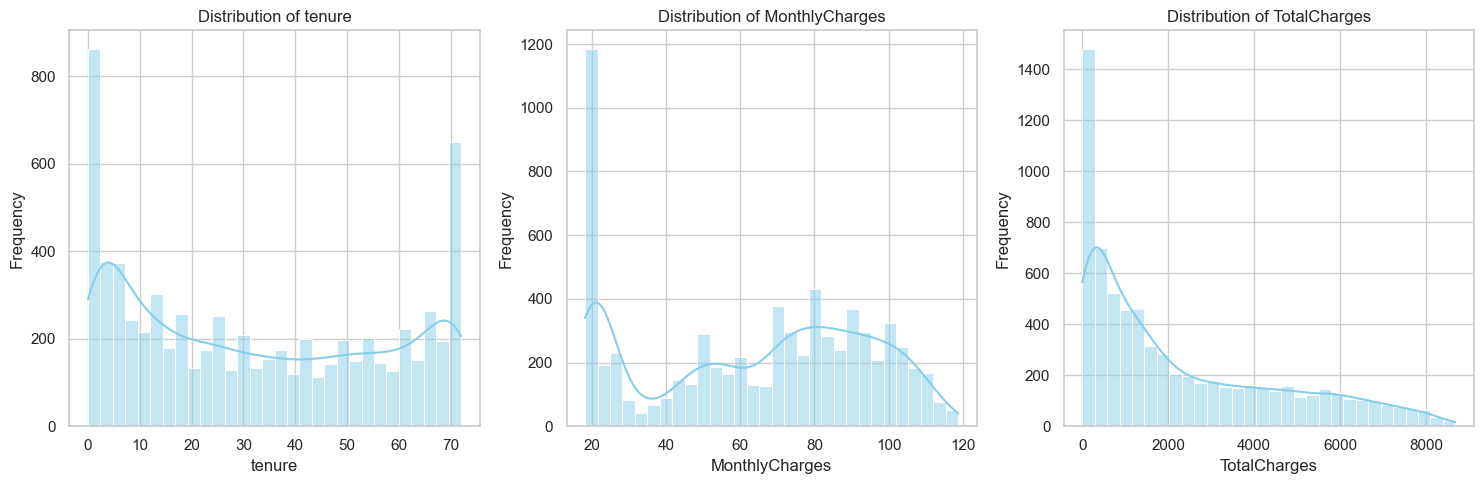

In [4]:
# Numerical features to analyze
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Histograms with KDE
plt.figure(figsize=(15, 5))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

These histograms show how each numeric feature is distributed. This helps identify skewness, gaps, or extreme values. For instance:
- `MonthlyCharges` may be right-skewed
- `TotalCharges` might need scaling or transformation

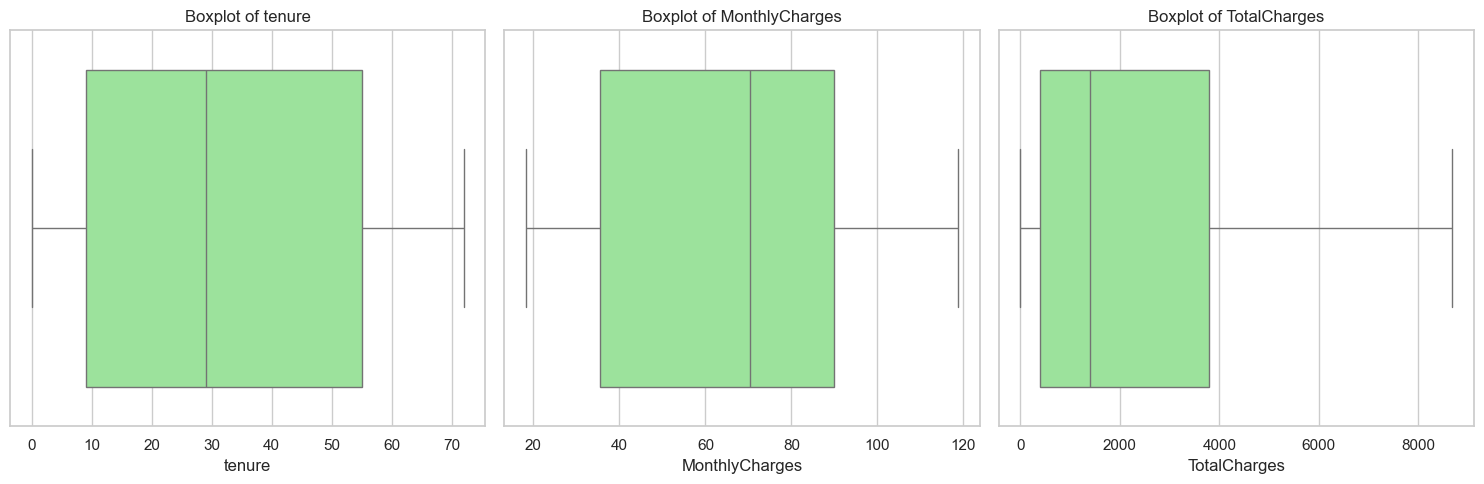

In [5]:
#  Boxplots to detect outliers
plt.figure(figsize=(15, 5))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x=feature, color='lightgreen')
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

Box plots reveal outliers in continuous variables. These outliers may influence model training and could be treated via winsorizing or transformation.

/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_80194/3279275723.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Blues_d")
/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_80194/3279275723.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Blues_d")
/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_80194/3279275723.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Blues_d")
/var/folders/03/f_3hssr15d79dbq0j2wfk

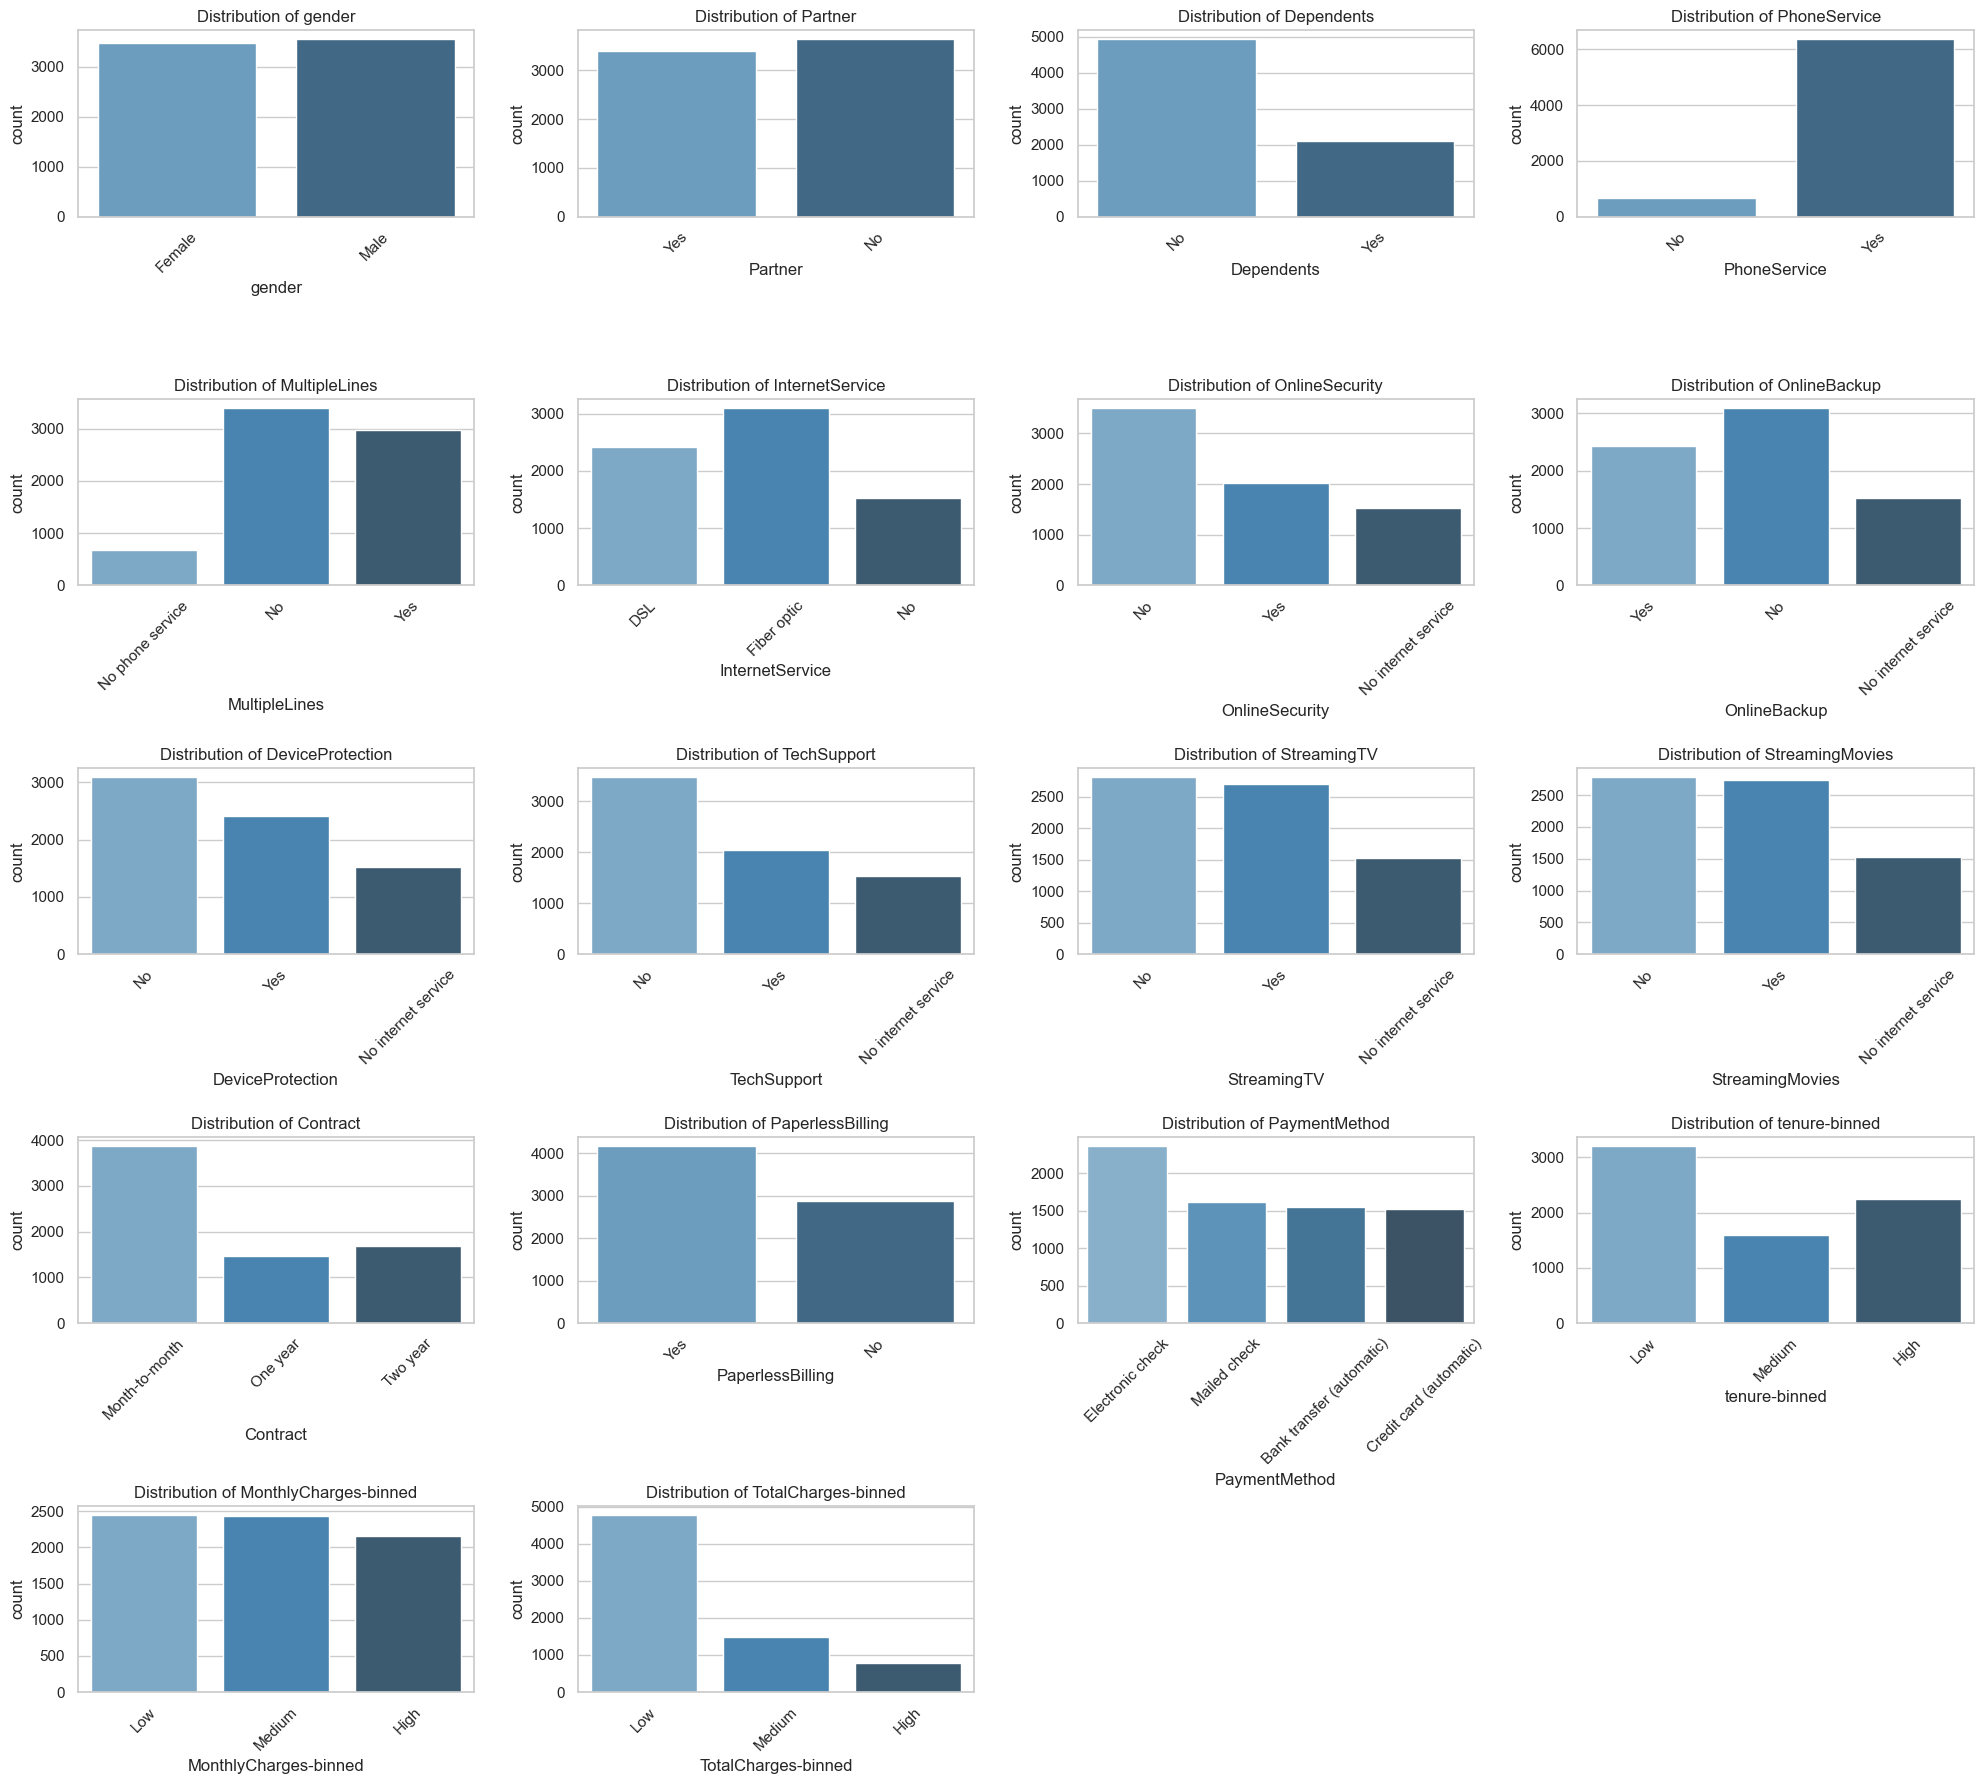

In [6]:
# Categorical features for count plots
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'tenure-binned',
    'MonthlyCharges-binned', 'TotalCharges-binned'
]

# Plot setup
plt.figure(figsize=(20, 18))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(5, 4, i)
    sns.countplot(data=df, x=feature, palette="Blues_d")
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

These bar charts display the frequency distribution of each categorical feature. They help us detect class imbalance, rare categories, and distribution trends in features like `Contract`, `Partner`, and `tenure-binned`.

## 🔁 Bivariate Analysis: Categorical Features vs Churn

This section explores how each **categorical feature** relates to the target variable `Churn`. We use grouped bar plots to visualize how different categories impact the churn rate.

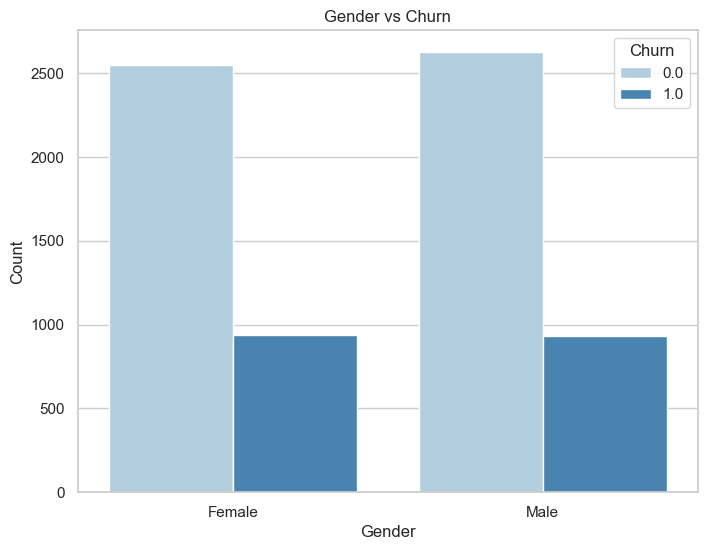

In [12]:
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', hue='Churn', data=df, palette='Blues')
plt.title('Gender vs Churn')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

💡 **Insight**: Gender has little to no influence on churn. Both males and females show a similar distribution, so it's not a strong predictive feature.

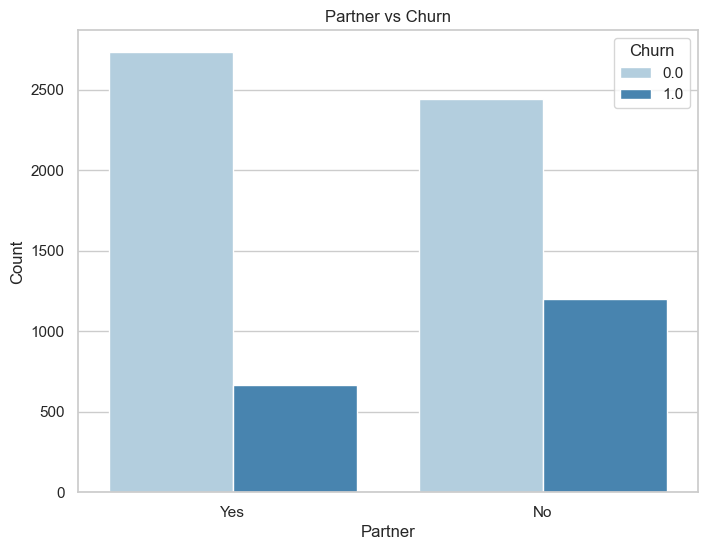

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Partner', hue='Churn', data=df, palette='Blues')
plt.title('Partner vs Churn')
plt.xlabel('Partner')
plt.ylabel('Count')
plt.show()

💡 **Insight**: Customers without partners are more likely to churn. This may suggest that customers with partners have more stable service needs.

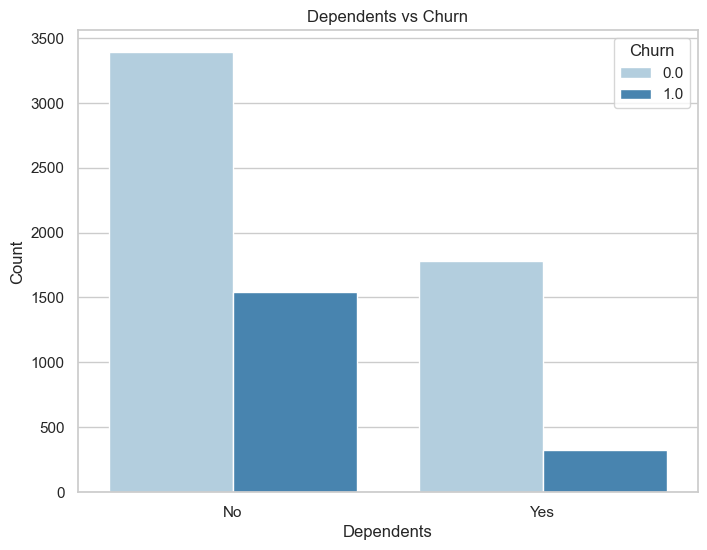

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Dependents', hue='Churn', data=df, palette='Blues')
plt.title('Dependents vs Churn')
plt.xlabel('Dependents')
plt.ylabel('Count')
plt.show()

💡 **Insight**: Customers with dependents churn less often. Possibly due to higher perceived service value or less volatility in switching providers.

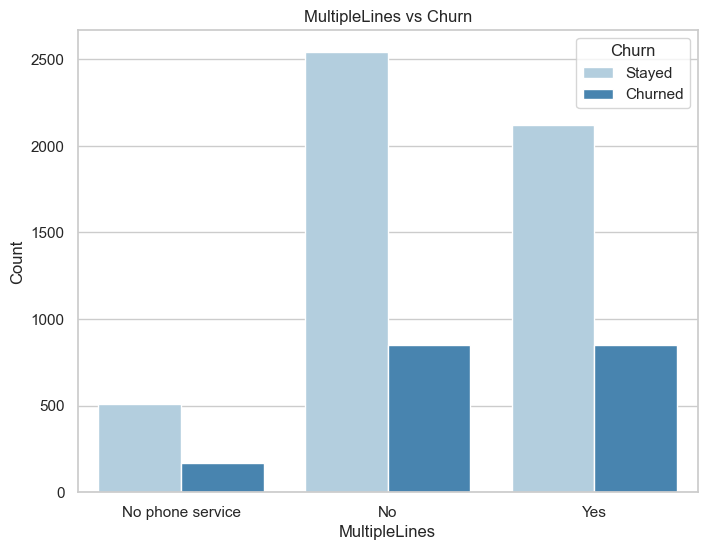

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(x='MultipleLines', hue='Churn', data=df, palette='Blues')
plt.title('MultipleLines vs Churn')
plt.xlabel('MultipleLines')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['Stayed', 'Churned'])
plt.show()

💡 **Insight**: No strong relationship observed. Multiple lines do not significantly change the likelihood of churn.

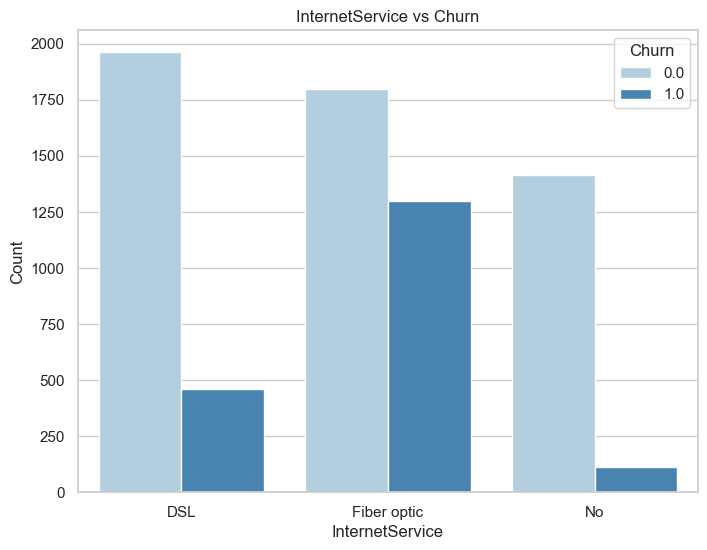

In [18]:
plt.figure(figsize=(8, 6))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Blues')
plt.title('InternetService vs Churn')
plt.xlabel('InternetService')
plt.ylabel('Count')
plt.show()

💡 **Insight**: Fiber optic users churn significantly more than DSL or those with no internet service. This might indicate dissatisfaction with cost or service reliability.

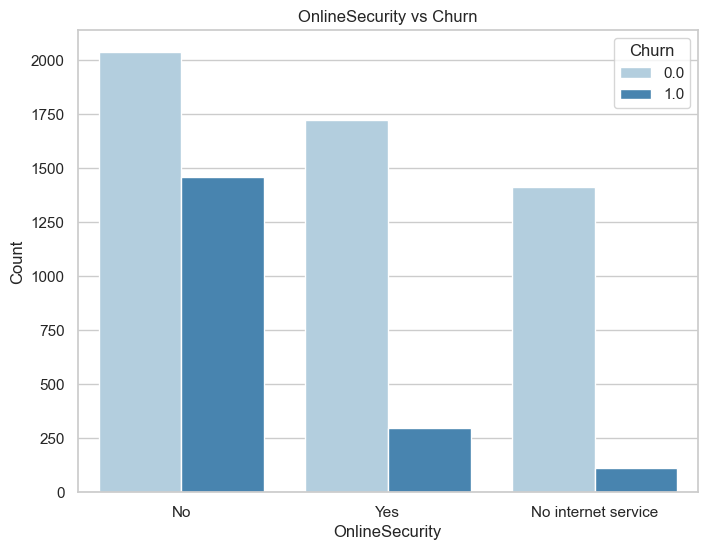

In [20]:
plt.figure(figsize=(8, 6))
sns.countplot(x='OnlineSecurity', hue='Churn', data=df, palette='Blues')
plt.title('OnlineSecurity vs Churn')
plt.xlabel('OnlineSecurity')
plt.ylabel('Count')
plt.show()

💡 **Insight**: Customers without online security services are more likely to churn. Security features may help retain users.

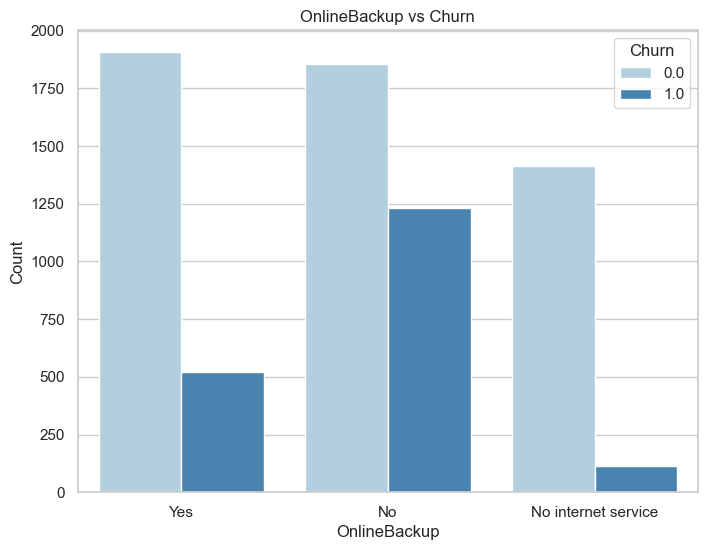

In [21]:
plt.figure(figsize=(8, 6))
sns.countplot(x='OnlineBackup', hue='Churn', data=df, palette='Blues')
plt.title('OnlineBackup vs Churn')
plt.xlabel('OnlineBackup')
plt.ylabel('Count')
plt.show()

💡 **Insight**: Users without online backup tend to churn more. Adding this feature may increase customer stickiness.

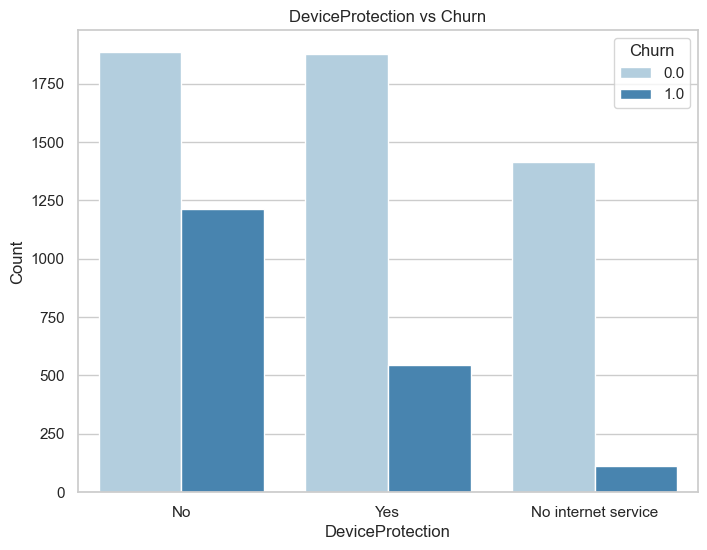

In [22]:
plt.figure(figsize=(8, 6))
sns.countplot(x='DeviceProtection', hue='Churn', data=df, palette='Blues')
plt.title('DeviceProtection vs Churn')
plt.xlabel('DeviceProtection')
plt.ylabel('Count')
plt.show()

💡 **Insight**: Customers with device protection are less likely to churn. This could indicate higher engagement and satisfaction.

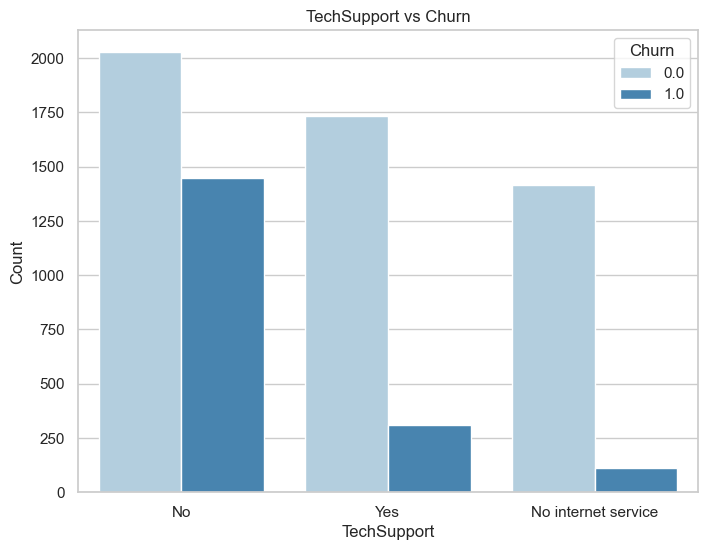

In [23]:
plt.figure(figsize=(8, 6))
sns.countplot(x='TechSupport', hue='Churn', data=df, palette='Blues')
plt.title('TechSupport vs Churn')
plt.xlabel('TechSupport')
plt.ylabel('Count')
plt.show()

💡 **Insight**: Having tech support services correlates with lower churn. This is a **strong predictive feature**.

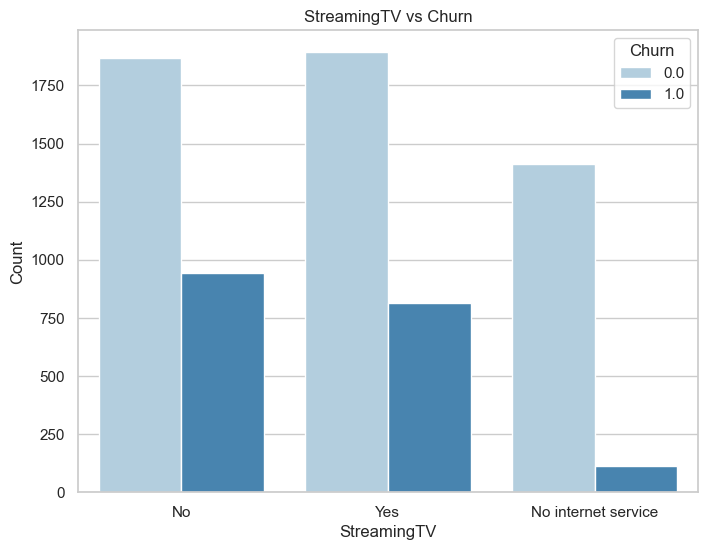

In [24]:
plt.figure(figsize=(8, 6))
sns.countplot(x='StreamingTV', hue='Churn', data=df, palette='Blues')
plt.title('StreamingTV vs Churn')
plt.xlabel('StreamingTV')
plt.ylabel('Count')
plt.show()

💡 **Insight**: No significant difference observed. StreamingTV does not strongly impact churn likelihood.

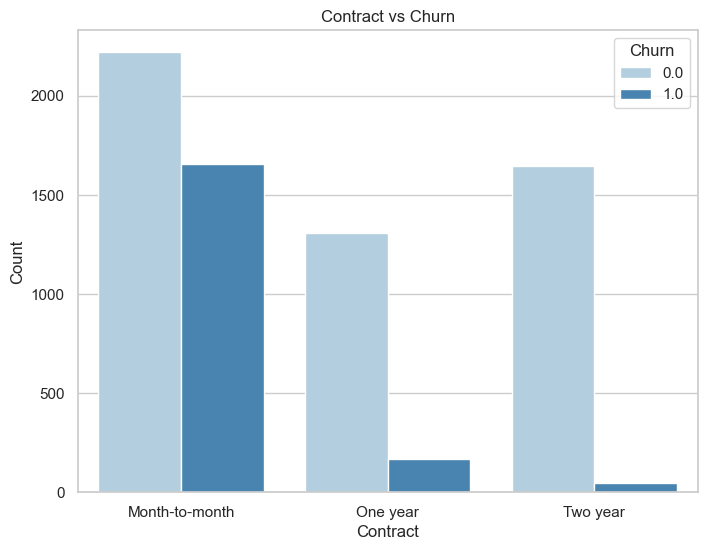

In [25]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Blues')
plt.title('Contract vs Churn')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.show()

💡 **Insight**: Month-to-month contracts have the **highest churn rate**. Long-term contracts significantly reduce churn. This is one of the **strongest signals** in the dataset.

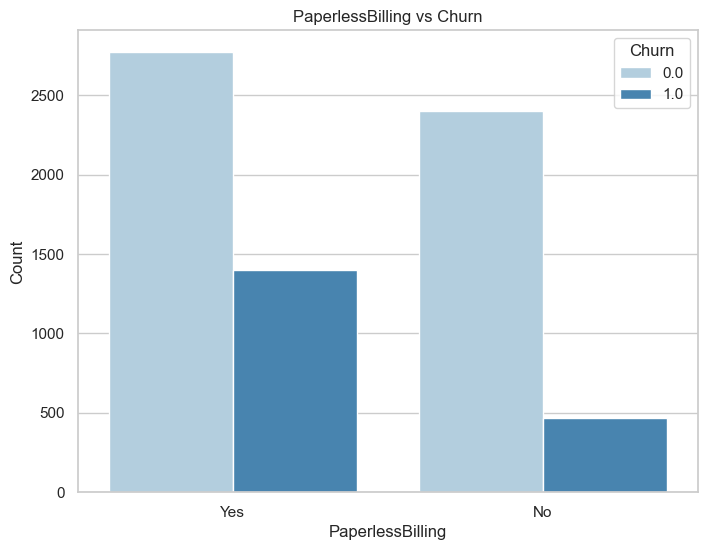

In [26]:
plt.figure(figsize=(8, 6))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df, palette='Blues')
plt.title('PaperlessBilling vs Churn')
plt.xlabel('PaperlessBilling')
plt.ylabel('Count')
plt.show()

💡 **Insight**: Paperless billing users tend to churn slightly more. May correlate with digital-native customers who switch providers easily.

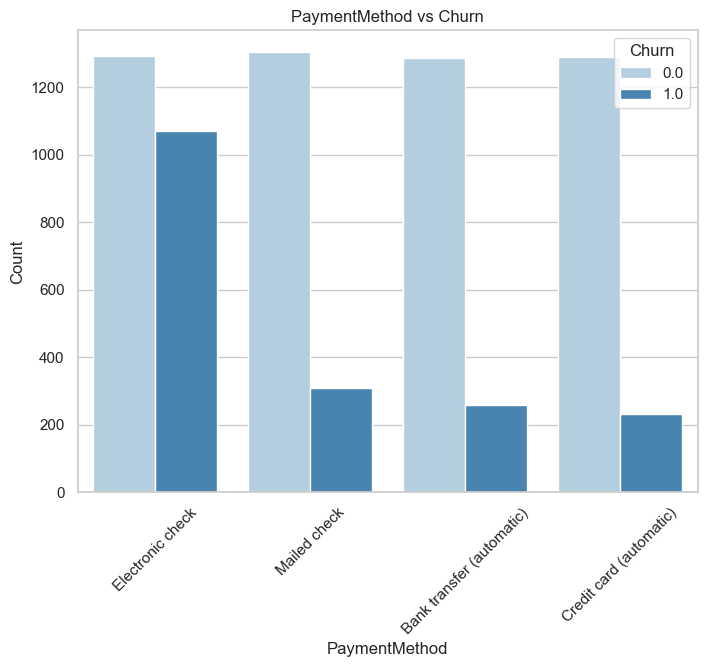

In [28]:
plt.figure(figsize=(8, 6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Blues')
plt.title('PaymentMethod vs Churn')
plt.xlabel('PaymentMethod')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

💡 **Insight**: Customers using electronic checks have a significantly higher churn rate. This could be related to budgeting, credit history, or perceived service value.

## 🔚 Summary of Categorical Insights

- **High churn** seen in: Fiber optic users, month-to-month contracts, electronic check payment
- **Lower churn** in: Customers with partners, dependents, tech support, device protection
- **Neutral impact**: Gender, Streaming services, MultipleLines

These insights are vital for:
- **Feature selection**
- **Business strategy** (e.g., upsell TechSupport, push long-term contracts)

## 📊 Bivariate Analysis: Categorical vs Continuous

In this section, we analyze how continuous variables behave across churn categories using box plots and violin plots. These visualizations help uncover distribution differences, medians, and outliers.

/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_61081/172938227.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Contract', y='MonthlyCharges', data=df, palette='Blues')


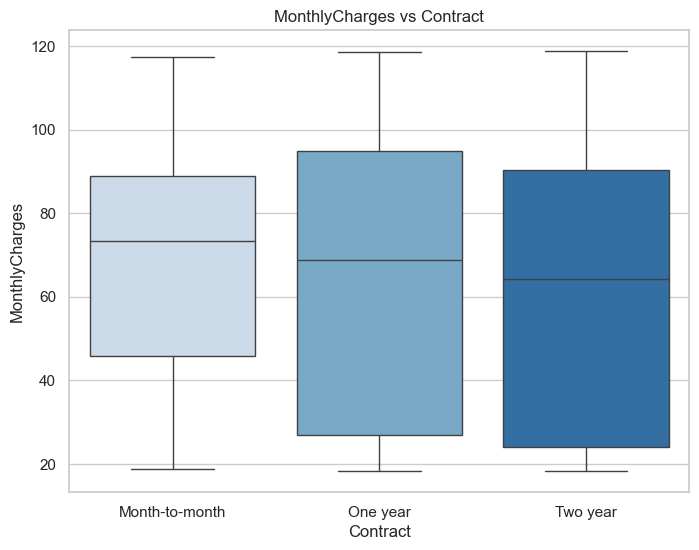

In [29]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Contract', y='MonthlyCharges', data=df, palette='Blues')
plt.title('MonthlyCharges vs Contract')
plt.xlabel('Contract')
plt.ylabel('MonthlyCharges')
plt.show()

💡 **Insight**: Customers on month-to-month contracts tend to have more varied and slightly higher monthly charges. This could indicate dissatisfaction with pricing or plan value, leading to higher churn.

/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_61081/2743238216.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=var, data=df, palette='Blues')
/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_61081/2743238216.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=var, data=df, palette='Blues')
/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_61081/2743238216.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=var, data=df, palette='Blues')


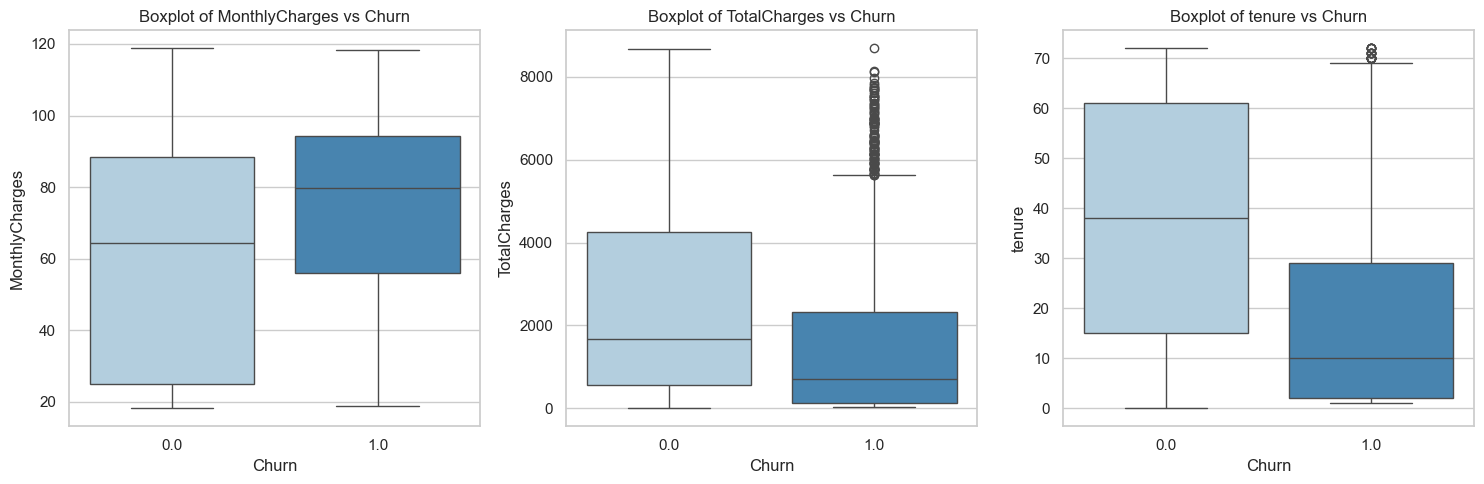

In [30]:
continuous_vars = ['MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))

for i, var in enumerate(continuous_vars, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Churn', y=var, data=df, palette='Blues')
    plt.title(f'Boxplot of {var} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(var)

plt.tight_layout()
plt.show()

💡 **Insights**:
- **MonthlyCharges**: Churned customers tend to have slightly higher charges → price sensitivity could be a factor.
- **TotalCharges**: Lower for churners → they are often newer customers.
- **Tenure**: Strongest pattern — churners usually have very short tenure.

📌 **Business Action**:
- Offer discounts or engagement to high-paying customers.
- Focus retention on customers with low tenure and low total charges.

/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_61081/37383166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn', y=var, data=df, palette='Blues')
/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_61081/37383166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn', y=var, data=df, palette='Blues')
/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_61081/37383166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn', y=var, data=df, palette='Blues')


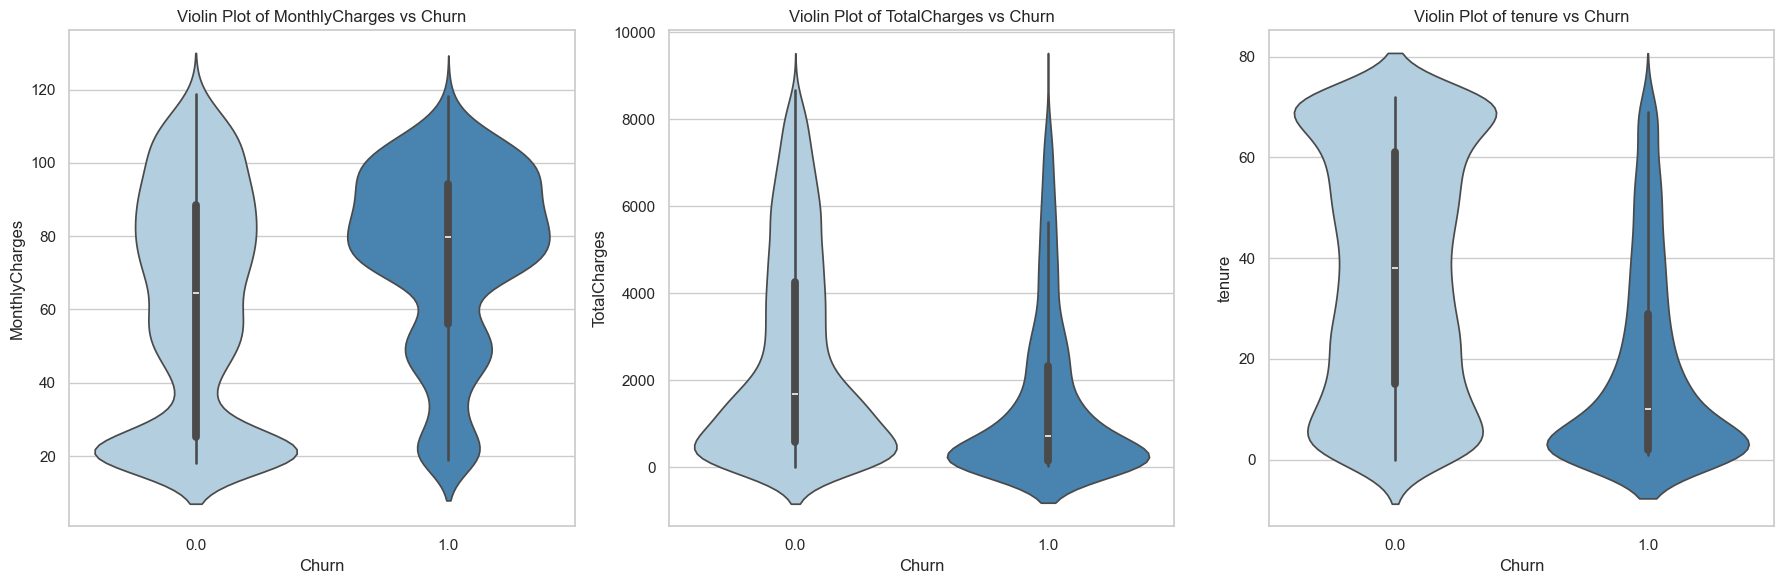

In [31]:
plt.figure(figsize=(18, 6))

for i, var in enumerate(continuous_vars, 1):
    plt.subplot(1, 3, i)
    sns.violinplot(x='Churn', y=var, data=df, palette='Blues')
    plt.title(f'Violin Plot of {var} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(var)

plt.tight_layout()
plt.show()

💡 **Insight**:
Violin plots reinforce box plot findings with richer detail. You can clearly see:
- Higher density of churners at **lower tenure and total charges**
- Wider spread of **MonthlyCharges** for churned customers

✅ These patterns strongly support feature importance for `tenure` and `TotalCharges`.

## 📈 Statistical Testing and Correlation Analysis

In this section, we use statistical tests to determine the significance of relationships between features and the target variable `Churn`.

---

### 🔍 Tests Performed:

- **Chi-Square Test**: For Categorical vs Categorical (e.g., `Partner` vs `Churn`)
- **ANOVA (F-Test)**: For Continuous vs Categorical (e.g., `MonthlyCharges` vs `Contract`)
- **Correlation Matrix**: For Continuous vs Continuous (e.g., `TotalCharges` vs `tenure`)

In [7]:
from scipy.stats import chi2_contingency
import pandas as pd

categorical_vars = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                    'PaperlessBilling', 'PaymentMethod']

def chi_square_test(df, categorical_vars, target='Churn'):
    results = {}
    for var in categorical_vars:
        table = pd.crosstab(df[var], df[target])
        chi2, p, _, _ = chi2_contingency(table)
        results[var] = p
        print(f"Chi-Square Test: {var} vs {target} → p-value = {p:.4f}")
    return results

chi_square_results = chi_square_test(df, categorical_vars)

Chi-Square Test: gender vs Churn → p-value = 0.4866
Chi-Square Test: Partner vs Churn → p-value = 0.0000
Chi-Square Test: Dependents vs Churn → p-value = 0.0000
Chi-Square Test: PhoneService vs Churn → p-value = 0.3388
Chi-Square Test: MultipleLines vs Churn → p-value = 0.0035
Chi-Square Test: InternetService vs Churn → p-value = 0.0000
Chi-Square Test: OnlineSecurity vs Churn → p-value = 0.0000
Chi-Square Test: OnlineBackup vs Churn → p-value = 0.0000
Chi-Square Test: DeviceProtection vs Churn → p-value = 0.0000
Chi-Square Test: TechSupport vs Churn → p-value = 0.0000
Chi-Square Test: StreamingTV vs Churn → p-value = 0.0000
Chi-Square Test: StreamingMovies vs Churn → p-value = 0.0000
Chi-Square Test: Contract vs Churn → p-value = 0.0000
Chi-Square Test: PaperlessBilling vs Churn → p-value = 0.0000
Chi-Square Test: PaymentMethod vs Churn → p-value = 0.0000


💡 **Interpretation**:
- Features with **p-value < 0.05** are statistically significant predictors of churn.
- Examples: `Partner`, `InternetService`, `Contract`, `TechSupport`, `OnlineSecurity`, `PaymentMethod`.

🧹 Less impactful: `gender`, `PhoneService`, `MultipleLines` showed higher p-values.

In [8]:
from scipy.stats import ttest_ind, f_oneway

def continuous_vs_categorical_tests(df, continuous_var, categorical_var):
    categories = df[categorical_var].dropna().unique()
    
    if len(categories) == 2:
        # Use T-Test for binary categorical variable
        group1 = df[df[categorical_var] == categories[0]][continuous_var]
        group2 = df[df[categorical_var] == categories[1]][continuous_var]
        stat, p = ttest_ind(group1, group2, equal_var=False)
        print(f"T-Test: {continuous_var} vs {categorical_var}")
        print(f"  Statistic = {stat:.4f}, p-value = {p:.4f}")
        if p < 0.05:
            print("  → Significant difference ✅\n")
        else:
            print("  → Not significant ❌\n")
    else:
        # Use ANOVA for multi-class categorical variable
        groups = [df[df[categorical_var] == cat][continuous_var] for cat in categories]
        stat, p = f_oneway(*groups)
        print(f"ANOVA: {continuous_var} vs {categorical_var}")
        print(f"  F-statistic = {stat:.4f}, p-value = {p:.4f}")
        if p < 0.05:
            print("  → Significant difference ✅\n")
        else:
            print("  → Not significant ❌\n")

# Run tests for both MonthlyCharges and TotalCharges
for cat in categorical_vars:
    continuous_vs_categorical_tests(df, 'MonthlyCharges', cat)
    continuous_vs_categorical_tests(df, 'TotalCharges', cat)

T-Test: MonthlyCharges vs gender
  Statistic = 1.2227, p-value = 0.2215
  → Not significant ❌

T-Test: TotalCharges vs gender
  Statistic = 0.0067, p-value = 0.9946
  → Not significant ❌

T-Test: MonthlyCharges vs Partner
  Statistic = 8.1482, p-value = 0.0000
  → Significant difference ✅

T-Test: TotalCharges vs Partner
  Statistic = 27.8623, p-value = 0.0000
  → Significant difference ✅

T-Test: MonthlyCharges vs Dependents
  Statistic = 9.3648, p-value = 0.0000
  → Significant difference ✅

T-Test: TotalCharges vs Dependents
  Statistic = -5.1558, p-value = 0.0000
  → Significant difference ✅

T-Test: MonthlyCharges vs PhoneService
  Statistic = -43.3605, p-value = 0.0000
  → Significant difference ✅

T-Test: TotalCharges vs PhoneService
  Statistic = -14.6837, p-value = 0.0000
  → Significant difference ✅

ANOVA: MonthlyCharges vs MultipleLines
  F-statistic = 1196.6457, p-value = 0.0000
  → Significant difference ✅

ANOVA: TotalCharges vs MultipleLines
  F-statistic = 991.8974, p-

💡 **Key Takeaways**:
- `MonthlyCharges` varies significantly with `Contract`, `InternetService`, `TechSupport`.
- `TotalCharges` shows strong differences across almost every service type.

📌 **Implication**: Pricing and service plans are tightly tied to customer retention.

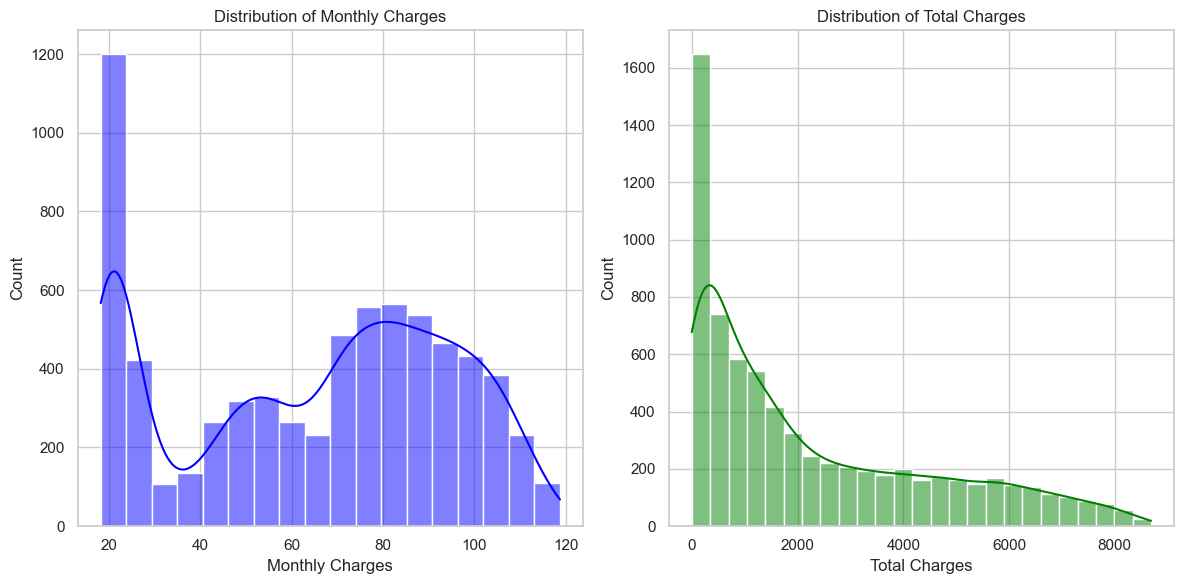

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# MonthlyCharges
plt.subplot(1, 2, 1)
sns.histplot(df['MonthlyCharges'], kde=True, color='blue')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')

# TotalCharges
plt.subplot(1, 2, 2)
sns.histplot(df['TotalCharges'], kde=True, color='green')
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')

plt.tight_layout()
plt.show()

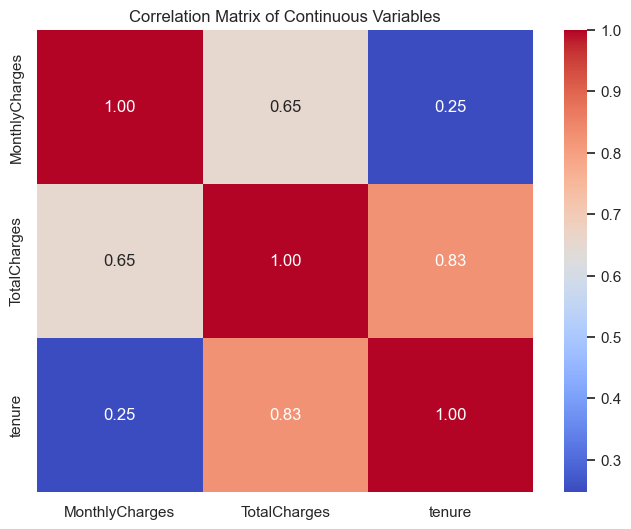

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['MonthlyCharges', 'TotalCharges', 'tenure']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Continuous Variables')
plt.show()

💡 **Insights**:
- `TotalCharges` and `tenure` are **strongly correlated** → long-tenure customers naturally accumulate charges.
- `MonthlyCharges` has weak correlation with tenure → pricing varies independently.

📌 Use `tenure` and `TotalCharges` carefully to avoid redundancy (e.g., consider dimensionality reduction or feature transformation).

## ✅ Key Findings from Statistical Testing

| Factor                | Churn Impact                            | Actionable Recommendation |
|-----------------------|------------------------------------------|----------------------------|
| Contract Type         | Month-to-month = high churn             | Push long-term contracts with offers |
| Tech Support & Security | No support/security → more churn       | Bundle these with basic plans |
| Internet Type         | DSL users churn more                    | Offer upgrade deals to fiber |
| Tenure                | Short-tenure = high churn               | Engage new users early (onboarding) |
| Payment Method        | Electronic check = more churn           | Promote automated payment options |
| Dependents            | Less churn for families                 | Target family plans |
| Paperless Billing     | Higher retention                        | Encourage switch to paperless |
| Streaming Services    | Some correlation to churn               | Improve service, or focus on core offerings |

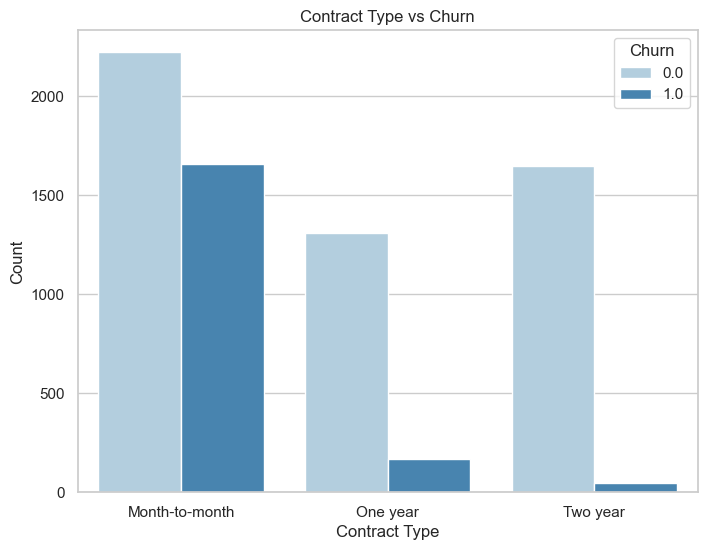

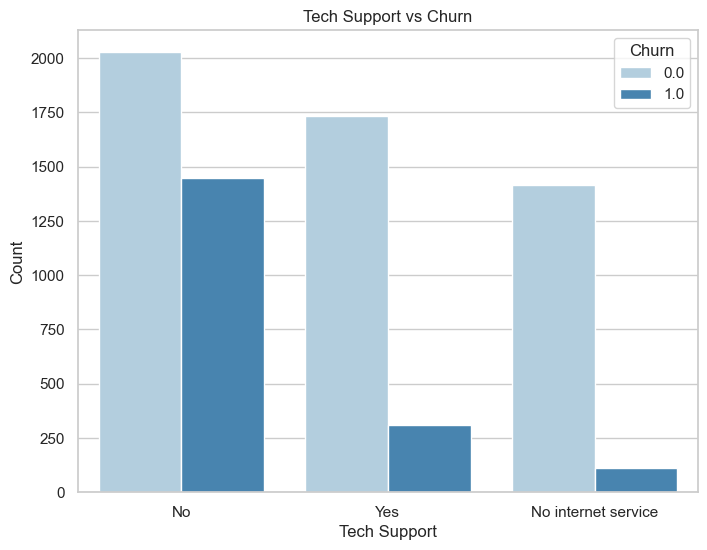

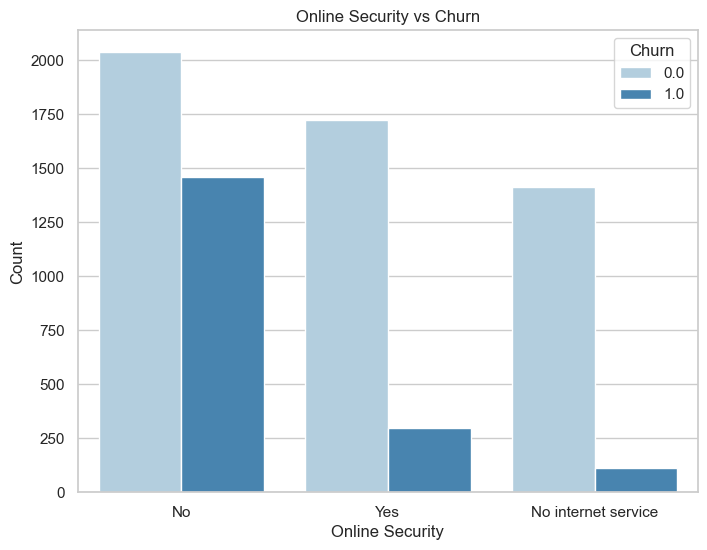

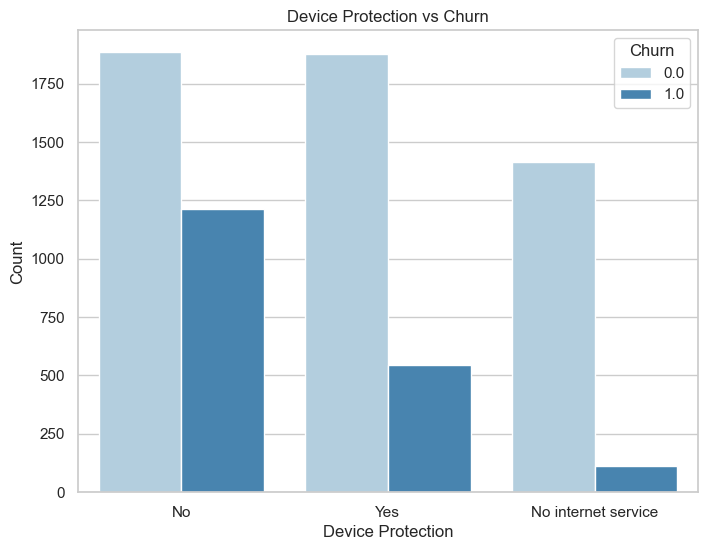

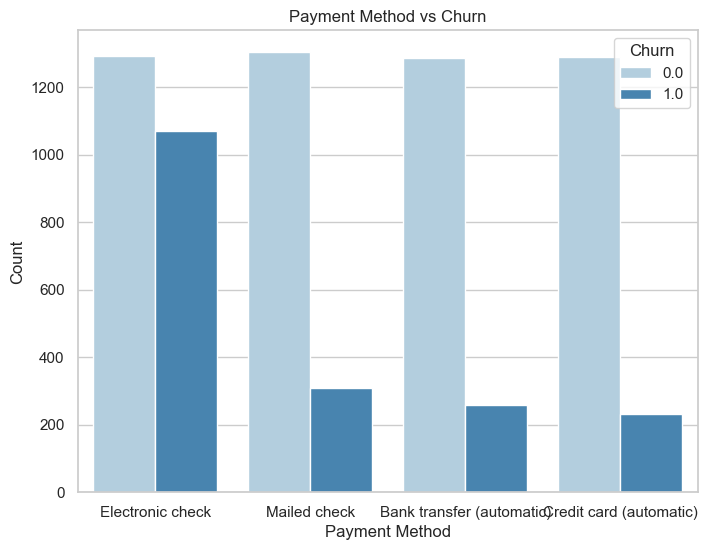

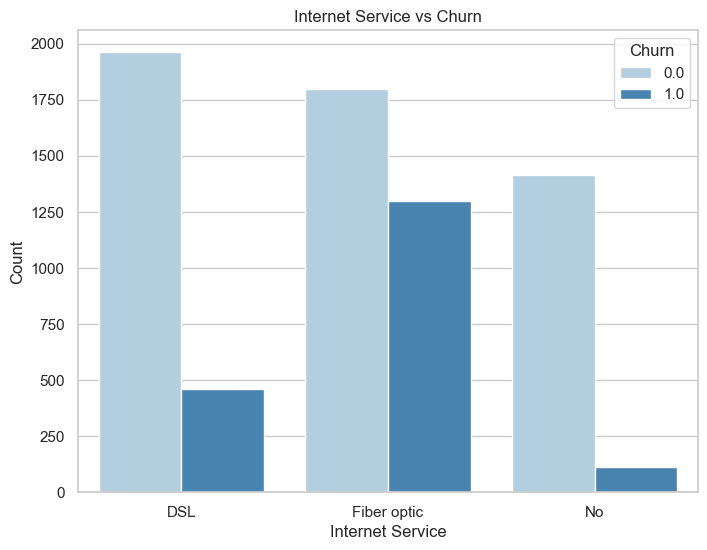

/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_61081/1247318994.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Blues')


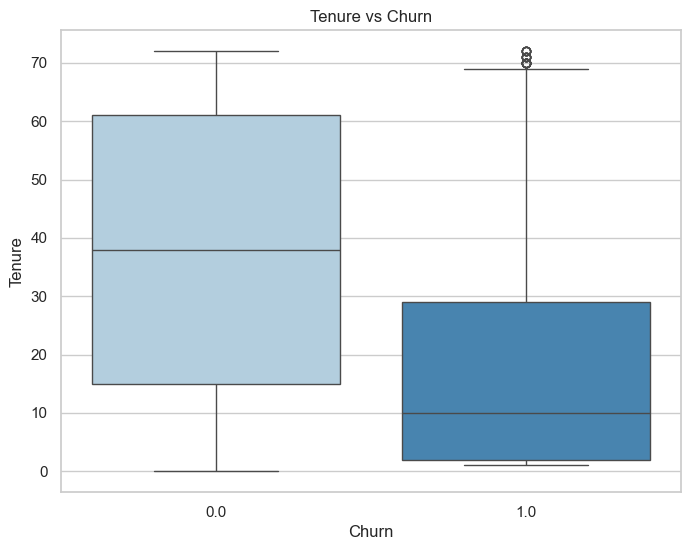

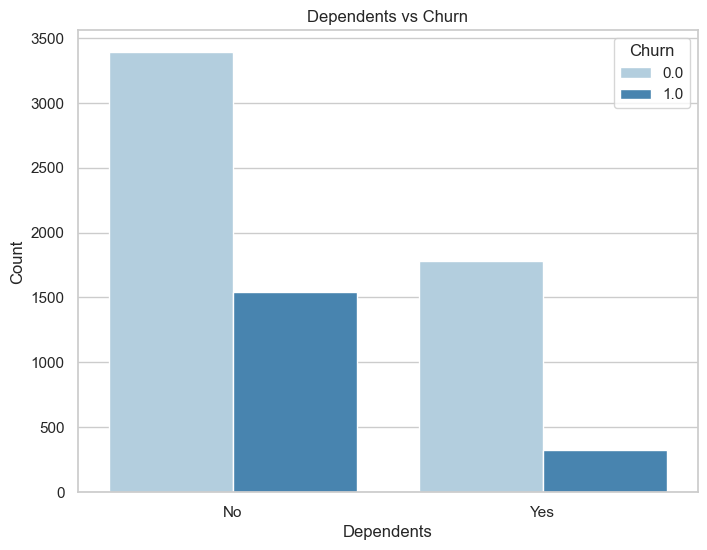

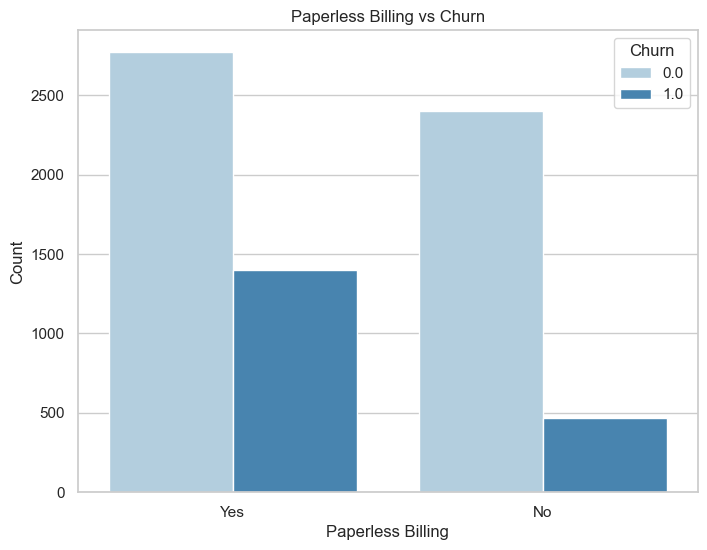

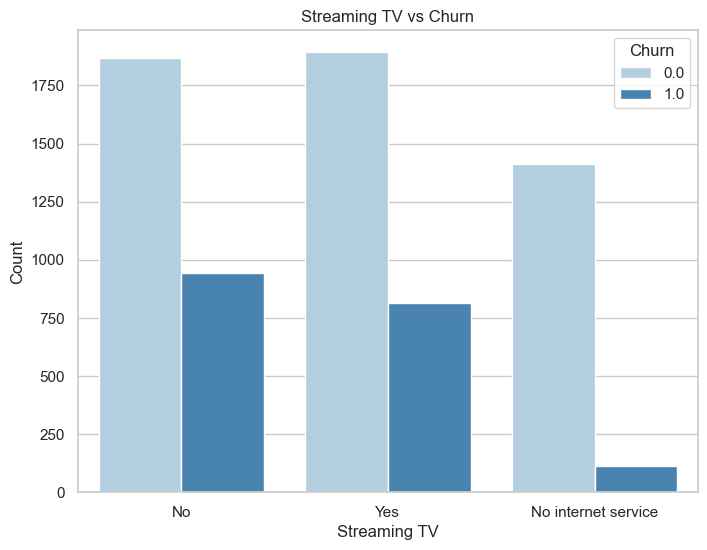

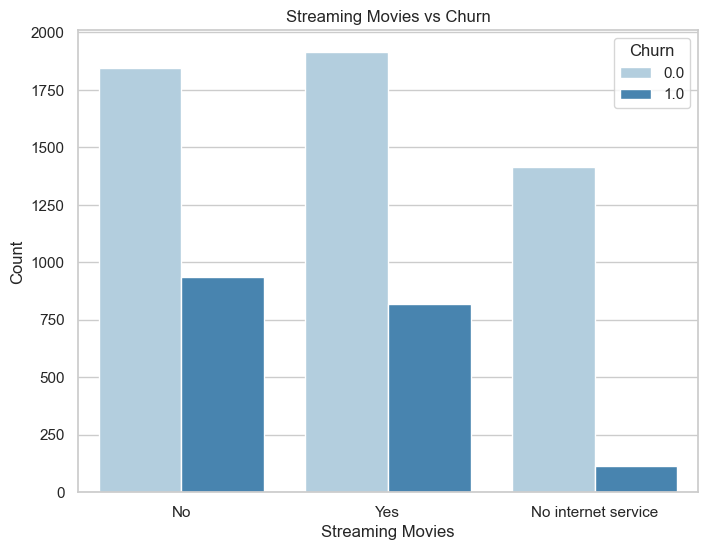

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Contract Type vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Blues')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

# Tech Support vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='Blues')
plt.title('Tech Support vs Churn')
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.show()

# Online Security vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn', palette='Blues')
plt.title('Online Security vs Churn')
plt.xlabel('Online Security')
plt.ylabel('Count')
plt.show()

# Device Protection vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='DeviceProtection', hue='Churn', palette='Blues')
plt.title('Device Protection vs Churn')
plt.xlabel('Device Protection')
plt.ylabel('Count')
plt.show()

# Payment Method vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Blues')
plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

# Internet Service vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Blues')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

# Tenure vs Churn
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='tenure', palette='Blues')
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

# Dependents vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Dependents', hue='Churn', palette='Blues')
plt.title('Dependents vs Churn')
plt.xlabel('Dependents')
plt.ylabel('Count')
plt.show()

# Paperless Billing vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='PaperlessBilling', hue='Churn', palette='Blues')
plt.title('Paperless Billing vs Churn')
plt.xlabel('Paperless Billing')
plt.ylabel('Count')
plt.show()

# Streaming TV vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='StreamingTV', hue='Churn', palette='Blues')
plt.title('Streaming TV vs Churn')
plt.xlabel('Streaming TV')
plt.ylabel('Count')
plt.show()

# Streaming Movies vs Churn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='StreamingMovies', hue='Churn', palette='Blues')
plt.title('Streaming Movies vs Churn')
plt.xlabel('Streaming Movies')
plt.ylabel('Count')
plt.show()

## 🛠️ Feature Engineering Summary

This section covers the complete transformation of raw data into model-ready features. We created meaningful indicators, encoded categorical variables, binned continuous features, and scaled numerical values.

### ✅ Key Transformations:
- Created binary features like `Tenure_Low`, `High_MonthlyCharges`, and `Has_TechSupport`.
- Engineered advanced features like `Services_Count`, `Satisfaction_Score`, and `TotalCharges_per_Month`.
- Binned `MonthlyCharges`, `TotalCharges`, and `tenure` into `Low`, `Medium`, and `High` categories.
- Label encoded binary variables and one-hot encoded multiclass categorical features.
- Removed original columns replaced by encoded or derived versions.
- Scaled only numerical features (`Satisfaction_Score`, `TotalCharges_per_Month`) using `StandardScaler`.

These transformations ensure that the dataset is clean, interpretable, and optimal for machine learning models.

In [10]:
# 1. Tenure Category: New vs Loyal
df['Tenure_Low'] = df['tenure'].apply(lambda x: 1 if x < 12 else 0)

# 2. Monthly Charges: High vs Low
median_monthly_charges = df['MonthlyCharges'].median()
df['High_MonthlyCharges'] = df['MonthlyCharges'].apply(lambda x: 1 if x > median_monthly_charges else 0)

# 3. Has Tech Support
df['Has_TechSupport'] = df['TechSupport'].apply(lambda x: 1 if x == "Yes" else 0)

# 4. Count of Services Used
df['Services_Count'] = df[['PhoneService', 'InternetService', 'StreamingTV', 'StreamingMovies']].apply(lambda x: sum(x == 'Yes'), axis=1)

# 5. Customer Satisfaction Score
df['Satisfaction_Score'] = df[['TechSupport', 'DeviceProtection', 'OnlineSecurity']].apply(lambda x: sum(x == 'Yes'), axis=1)

# 6. Contract Commitment Indicator
df['Is_MonthToMonth'] = df['Contract'].apply(lambda x: 1 if x == "Month-to-month" else 0)

# 7. Total Charges per Month (Avoid divide by zero)
df['TotalCharges_per_Month'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# 8. Fiber Optic Flag
df['Is_FiberOptic'] = df['InternetService'].apply(lambda x: 1 if x == "Fiber optic" else 0)

# 9. Has Dependents
df['Has_Dependents'] = df['Dependents'].apply(lambda x: 1 if x == "Yes" else 0)

# 10. Paperless Billing Flag
df['Is_Paperless'] = df['PaperlessBilling'].apply(lambda x: 1 if x == "Yes" else 0)

In [11]:
# MonthlyCharges bins
df['MonthlyCharges_binned'] = pd.cut(df['MonthlyCharges'], bins=[0, 50, 100, float('inf')], labels=['Low', 'Medium', 'High'], right=False)

# TotalCharges bins
df['TotalCharges_binned'] = pd.cut(df['TotalCharges'], bins=[0, 1500, 5000, float('inf')], labels=['Low', 'Medium', 'High'], right=False)

# Tenure bins
df['Tenure_binned'] = pd.cut(df['tenure'].replace(0, 1), bins=[0, 12, 36, float('inf')], labels=['New', 'Medium', 'Old'], right=False)

In [12]:
columns_to_remove = [
    'tenure', 'TechSupport', 'PhoneService', 'MultipleLines',
    'InternetService', 'Dependents', 'PaperlessBilling',
    'MonthlyCharges', 'TotalCharges'
]

df = df.drop(columns=columns_to_remove, errors='ignore')

In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_cols = ['SeniorCitizen', 'Churn', 'Tenure_Low', 'Has_TechSupport', 'Is_MonthToMonth', 'Has_Dependents', 'Is_Paperless']
le = LabelEncoder()

for col in label_cols:
    df[col + '_Encoded'] = le.fit_transform(df[col])

In [16]:
# Define the full list of original intended categorical columns
one_hot_cols = [
    'Contract', 'PaymentMethod', 'InternetService', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

# Filter the list to include only columns that still exist in df
existing_one_hot_cols = [col for col in one_hot_cols if col in df.columns]

# Apply one-hot encoding to available columns only
df = pd.get_dummies(df, columns=existing_one_hot_cols, drop_first=True)

# Confirm the update
print("✅ One-hot encoding completed. New shape:", df.shape)

✅ One-hot encoding completed. New shape: (7043, 42)


In [17]:
# Drop only if columns exist
for col in ['gender', 'Partner', 'Dependents', 'PaperlessBilling']:
    if col in df.columns:
        df = df.drop(columns=col)

print("✅ After dropping selected columns:", df.columns.tolist())

✅ After dropping selected columns: ['SeniorCitizen', 'tenure-binned', 'MonthlyCharges-binned', 'TotalCharges-binned', 'Churn', 'Tenure_Low', 'High_MonthlyCharges', 'Has_TechSupport', 'Services_Count', 'Satisfaction_Score', 'Is_MonthToMonth', 'TotalCharges_per_Month', 'Is_FiberOptic', 'Has_Dependents', 'Is_Paperless', 'MonthlyCharges_binned', 'TotalCharges_binned', 'Tenure_binned', 'SeniorCitizen_Encoded', 'Churn_Encoded', 'Tenure_Low_Encoded', 'Has_TechSupport_Encoded', 'Is_MonthToMonth_Encoded', 'Has_Dependents_Encoded', 'Is_Paperless_Encoded', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes']


In [18]:
# Drop 'SeniorCitizen' if both original and encoded versions exist
if 'SeniorCitizen' in df.columns and 'SeniorCitizen_Encoded' in df.columns:
    df = df.drop(columns=['SeniorCitizen'])

print("✅ After checking SeniorCitizen:", df.columns.tolist())

✅ After checking SeniorCitizen: ['tenure-binned', 'MonthlyCharges-binned', 'TotalCharges-binned', 'Churn', 'Tenure_Low', 'High_MonthlyCharges', 'Has_TechSupport', 'Services_Count', 'Satisfaction_Score', 'Is_MonthToMonth', 'TotalCharges_per_Month', 'Is_FiberOptic', 'Has_Dependents', 'Is_Paperless', 'MonthlyCharges_binned', 'TotalCharges_binned', 'Tenure_binned', 'SeniorCitizen_Encoded', 'Churn_Encoded', 'Tenure_Low_Encoded', 'Has_TechSupport_Encoded', 'Is_MonthToMonth_Encoded', 'Has_Dependents_Encoded', 'Is_Paperless_Encoded', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes']


In [19]:
# Drop duplicates in column names (very safe step)
df = df.loc[:, ~df.columns.duplicated()]

# Drop binned columns only if they exist
for col in ['MonthlyCharges_binned', 'TotalCharges_binned', 'Tenure_binned']:
    if col in df.columns:
        df = df.drop(columns=col)

print("✅ After dropping binned/duplicate columns:", df.columns.tolist())

✅ After dropping binned/duplicate columns: ['tenure-binned', 'MonthlyCharges-binned', 'TotalCharges-binned', 'Churn', 'Tenure_Low', 'High_MonthlyCharges', 'Has_TechSupport', 'Services_Count', 'Satisfaction_Score', 'Is_MonthToMonth', 'TotalCharges_per_Month', 'Is_FiberOptic', 'Has_Dependents', 'Is_Paperless', 'SeniorCitizen_Encoded', 'Churn_Encoded', 'Tenure_Low_Encoded', 'Has_TechSupport_Encoded', 'Is_MonthToMonth_Encoded', 'Has_Dependents_Encoded', 'Is_Paperless_Encoded', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes']


In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Safe label encoding if columns still exist
for col in ['gender', 'Partner', 'Dependents', 'PaperlessBilling']:
    if col in df.columns:
        df[col + '_Encoded'] = label_encoder.fit_transform(df[col])
        df = df.drop(columns=col)

print("✅ After label encoding remaining categoricals:", df.columns.tolist())

✅ After label encoding remaining categoricals: ['tenure-binned', 'MonthlyCharges-binned', 'TotalCharges-binned', 'Churn', 'Tenure_Low', 'High_MonthlyCharges', 'Has_TechSupport', 'Services_Count', 'Satisfaction_Score', 'Is_MonthToMonth', 'TotalCharges_per_Month', 'Is_FiberOptic', 'Has_Dependents', 'Is_Paperless', 'SeniorCitizen_Encoded', 'Churn_Encoded', 'Tenure_Low_Encoded', 'Has_TechSupport_Encoded', 'Is_MonthToMonth_Encoded', 'Has_Dependents_Encoded', 'Is_Paperless_Encoded', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes']


In [21]:
from sklearn.preprocessing import StandardScaler

columns_to_scale = ['Satisfaction_Score', 'TotalCharges_per_Month']
columns_to_scale = [col for col in columns_to_scale if col in df.columns]

scaler = StandardScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Show preview of scaled features
print("✅ Scaled feature preview:")
print(df[columns_to_scale].head())

✅ Scaled feature preview:
   Satisfaction_Score  TotalCharges_per_Month
0           -0.901228               -1.151302
1            1.056320               -0.301458
2            0.077546               -0.350966
3            2.035093               -0.786053
4           -0.901228                0.367602


In [22]:
# One-hot encoding the binned columns
df = pd.get_dummies(df, columns=['MonthlyCharges-binned', 'TotalCharges-binned', 'tenure-binned'], drop_first=True)

# Check resulting columns
print(df.columns)

Index(['Churn', 'Tenure_Low', 'High_MonthlyCharges', 'Has_TechSupport',
       'Services_Count', 'Satisfaction_Score', 'Is_MonthToMonth',
       'TotalCharges_per_Month', 'Is_FiberOptic', 'Has_Dependents',
       'Is_Paperless', 'SeniorCitizen_Encoded', 'Churn_Encoded',
       'Tenure_Low_Encoded', 'Has_TechSupport_Encoded',
       'Is_MonthToMonth_Encoded', 'Has_Dependents_Encoded',
       'Is_Paperless_Encoded', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'MonthlyCharges-binned_Low', 'MonthlyCharges-binned_Medium',
       'TotalCharges-b

In [23]:
# Define features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Check for missing values
print(X.isnull().sum())
print(y.isnull().sum())

# Fill missing values in TotalCharges_per_Month
X['TotalCharges_per_Month'].fillna(X['TotalCharges_per_Month'].median(), inplace=True)

Tenure_Low                               0
High_MonthlyCharges                      0
Has_TechSupport                          0
Services_Count                           0
Satisfaction_Score                       0
Is_MonthToMonth                          0
TotalCharges_per_Month                   0
Is_FiberOptic                            0
Has_Dependents                           0
Is_Paperless                             0
SeniorCitizen_Encoded                    0
Churn_Encoded                            0
Tenure_Low_Encoded                       0
Has_TechSupport_Encoded                  0
Is_MonthToMonth_Encoded                  0
Has_Dependents_Encoded                   0
Is_Paperless_Encoded                     0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
OnlineSecurity_No internet service       0
OnlineSecur

/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_80194/179207358.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['TotalCharges_per_Month'].fillna(X['TotalCharges_per_Month'].median(), inplace=True)


In [24]:
from sklearn.model_selection import train_test_split

# Use encoded churn column
X = df.drop(columns=['Churn', 'Churn_Encoded'])
y = df['Churn_Encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check shapes
print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (5634, 37)
Testing data size: (1409, 37)


In [25]:
# Fill missing values in TotalCharges_per_Month
X_train['TotalCharges_per_Month'].fillna(X_train['TotalCharges_per_Month'].median(), inplace=True)
X_test['TotalCharges_per_Month'].fillna(X_test['TotalCharges_per_Month'].median(), inplace=True)

# Confirm no missing
print("Training missing:\n", X_train.isnull().sum())
print("Testing missing:\n", X_test.isnull().sum())

Training missing:
 Tenure_Low                               0
High_MonthlyCharges                      0
Has_TechSupport                          0
Services_Count                           0
Satisfaction_Score                       0
Is_MonthToMonth                          0
TotalCharges_per_Month                   0
Is_FiberOptic                            0
Has_Dependents                           0
Is_Paperless                             0
SeniorCitizen_Encoded                    0
Tenure_Low_Encoded                       0
Has_TechSupport_Encoded                  0
Is_MonthToMonth_Encoded                  0
Has_Dependents_Encoded                   0
Is_Paperless_Encoded                     0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                 

/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_80194/867314891.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['TotalCharges_per_Month'].fillna(X_train['TotalCharges_per_Month'].median(), inplace=True)
/var/folders/03/f_3hssr15d79dbq0j2wfkkn80000gn/T/ipykernel_80194/867314891.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the interme

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))

Logistic Regression
Accuracy: 0.8062455642299503
Confusion Matrix:
 [[938  98]
 [175 198]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.758694109297374
Confusion Matrix:
 [[907 129]
 [211 162]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84      1036
           1       0.56      0.43      0.49       373

    accuracy                           0.76      1409
   macro avg       0.68      0.65      0.67      1409
weighted avg       0.74      0.76      0.75      1409



In [28]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Classifier
Accuracy: 0.7863733144073811
Confusion Matrix:
 [[913 123]
 [178 195]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1036
           1       0.61      0.52      0.56       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [29]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='linear', class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM
Accuracy: 0.7061745919091554
Confusion Matrix:
 [[674 362]
 [ 52 321]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.65      0.77      1036
           1       0.47      0.86      0.61       373

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.72      1409



In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

KNN
Accuracy: 0.78708303761533
Confusion Matrix:
 [[913 123]
 [177 196]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1036
           1       0.61      0.53      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [31]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier()
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm))
print("Classification Report:\n", classification_report(y_test, y_pred_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 332
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418
LightGBM
Accuracy: 0.7934705464868701
Confusion Matrix:
 [[926 110]
 [181 192]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.64      0.51      0.57       373

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72 

In [32]:
from catboost import CatBoostClassifier

catboost = CatBoostClassifier(iterations=1000, depth=10, learning_rate=0.1, verbose=0)
catboost.fit(X_train, y_train)
y_pred_catboost = catboost.predict(X_test)

print("CatBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_catboost))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_catboost))
print("Classification Report:\n", classification_report(y_test, y_pred_catboost))

CatBoost
Accuracy: 0.7622427253371186
Confusion Matrix:
 [[892 144]
 [191 182]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84      1036
           1       0.56      0.49      0.52       373

    accuracy                           0.76      1409
   macro avg       0.69      0.67      0.68      1409
weighted avg       0.75      0.76      0.76      1409



In [33]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=1)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("MLP Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))
print("Classification Report:\n", classification_report(y_test, y_pred_mlp))

MLP Classifier
Accuracy: 0.7707594038325053
Confusion Matrix:
 [[862 174]
 [149 224]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      1036
           1       0.56      0.60      0.58       373

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



/Users/zeeshanabbasi/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [34]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Classification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting
Accuracy: 0.8069552874378992
Confusion Matrix:
 [[938  98]
 [174 199]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [35]:
# Save the cleaned dataset
df.to_csv("cleaned_customer_churn_dataset.csv", index=False)

# Optional: Confirm it's saved
print("✅ Cleaned dataset saved as 'cleaned_customer_churn_dataset.csv'")

✅ Cleaned dataset saved as 'cleaned_customer_churn_dataset.csv'


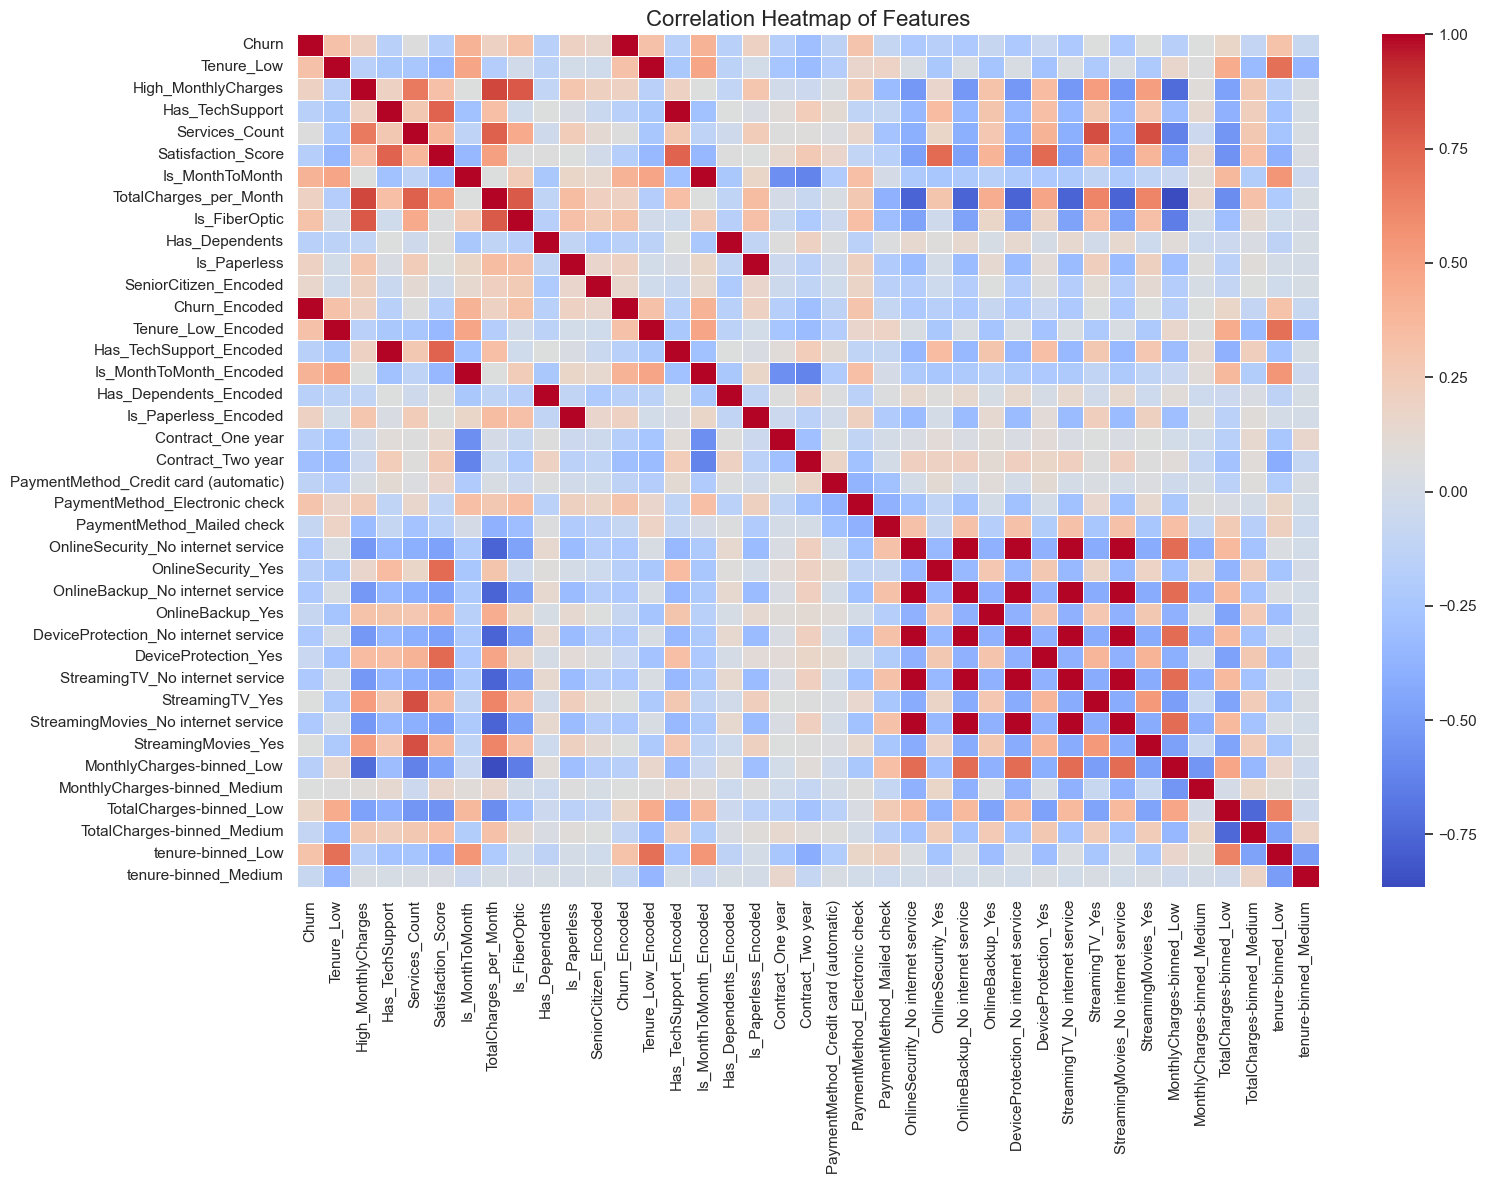

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features', fontsize=16)
plt.tight_layout()
plt.show()

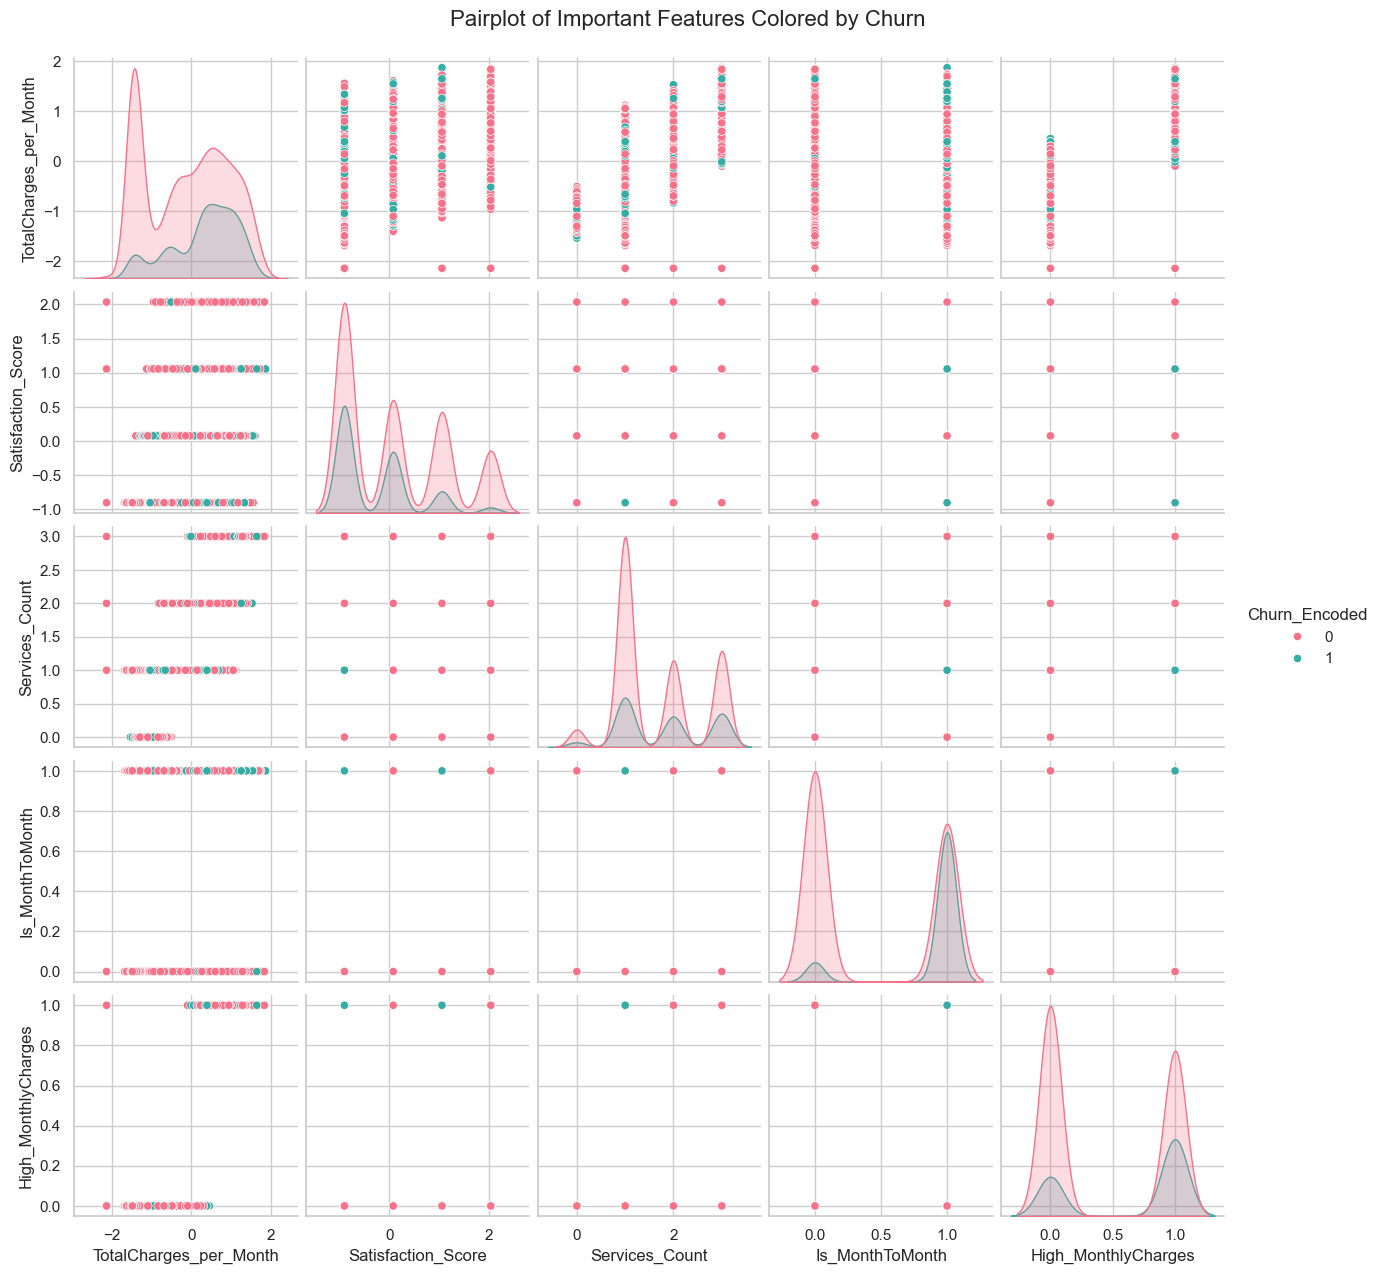

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select a few top features based on importance/EDA
pairplot_features = [
    'TotalCharges_per_Month',
    'Satisfaction_Score',
    'Services_Count',
    'Is_MonthToMonth',
    'High_MonthlyCharges',
    'Churn_Encoded'
]

# Subset the DataFrame
df_pairplot = df[pairplot_features]

# Plot pairplot
sns.pairplot(df_pairplot, hue='Churn_Encoded', palette='husl', diag_kind='kde')
plt.suptitle('Pairplot of Important Features Colored by Churn', y=1.02, fontsize=16)
plt.show()

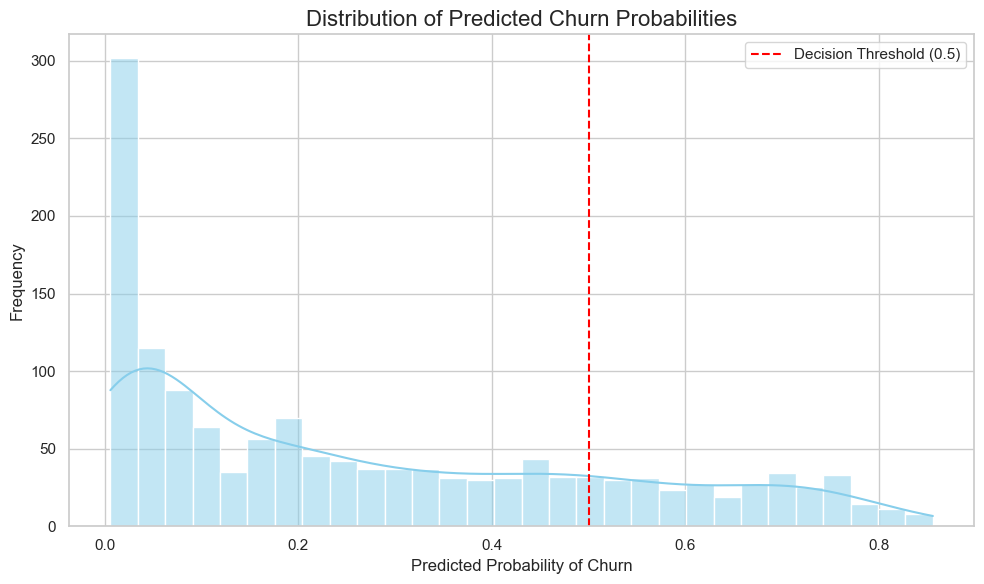

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get churn probabilities from logistic regression model
y_pred_prob = logreg.predict_proba(X_test)[:, 1]  # Probabilities of class 1 (Churned)

# Plot distribution of churn probabilities
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_prob, bins=30, kde=True, color='skyblue')
plt.axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title('Distribution of Predicted Churn Probabilities', fontsize=16)
plt.xlabel('Predicted Probability of Churn')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Initialize the model
lr = LogisticRegression(max_iter=1000)

# Grid search
grid_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_lr.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_lr.best_params_)
print("Best Accuracy:", grid_lr.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy: 0.7962353093218135


In [41]:
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best Accuracy:", grid_rf.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy: 0.7937524133137693


In [42]:
from sklearn.model_selection import cross_val_score

# Use the best estimator from GridSearchCV
best_lr = grid_lr.best_estimator_

# Perform 5-fold cross-validation
cv_scores_lr = cross_val_score(best_lr, X_train, y_train, cv=5, scoring='accuracy')

# Output results
print("Logistic Regression CV Scores:", cv_scores_lr)
print("Logistic Regression CV Mean Accuracy:", cv_scores_lr.mean())

Logistic Regression CV Scores: [0.80390417 0.80390417 0.80301686 0.78438332 0.78596803]
Logistic Regression CV Mean Accuracy: 0.7962353093218135


In [43]:
# Use the best estimator from GridSearchCV
best_rf = grid_rf.best_estimator_

# Perform 5-fold cross-validation
cv_scores_rf = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='accuracy')

# Output results
print("Random Forest CV Scores:", cv_scores_rf)
print("Random Forest CV Mean Accuracy:", cv_scores_rf.mean())

Random Forest CV Scores: [0.80301686 0.79769299 0.78881988 0.78438332 0.79484902]
Random Forest CV Mean Accuracy: 0.7937524133137693


In [45]:
from sklearn.model_selection import cross_val_score

# Logistic Regression
logreg_cv = cross_val_score(logreg, X_train, y_train, cv=5, scoring='accuracy')
mean_logreg = logreg_cv.mean()

# Random Forest
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
mean_rf = rf_cv.mean()

# XGBoost
xgb_cv = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')
mean_xgb = xgb_cv.mean()

# Print the scores (optional)
print("Logistic Regression CV Accuracy:", mean_logreg)
print("Random Forest CV Accuracy:", mean_rf)
print("XGBoost CV Accuracy:", mean_xgb)

Logistic Regression CV Accuracy: 0.7948162414243634
Random Forest CV Accuracy: 0.7639338629883957
XGBoost CV Accuracy: 0.772986015782481


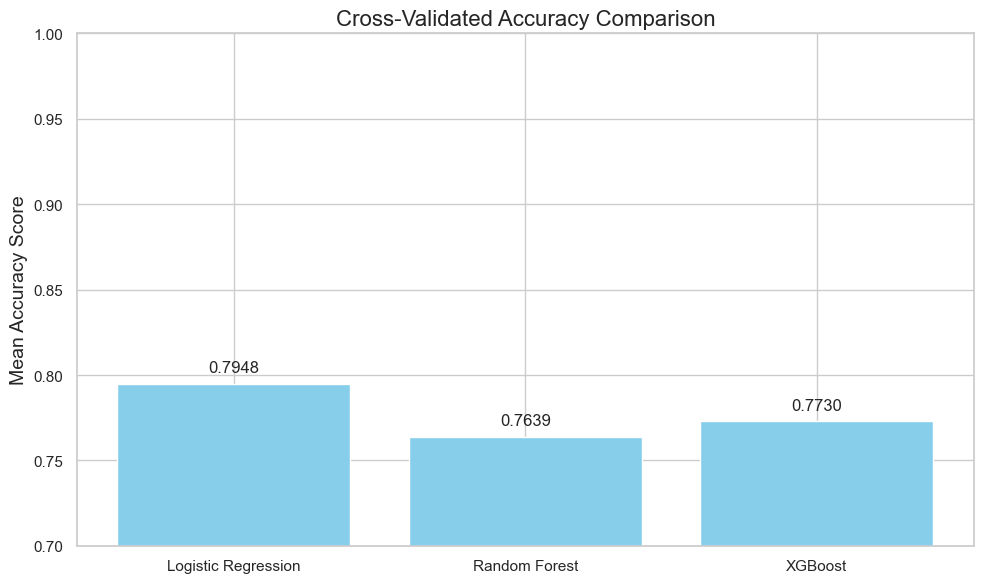

In [46]:
import matplotlib.pyplot as plt

# Names and scores
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
best_scores = [mean_logreg, mean_rf, mean_xgb]

# Bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, best_scores, color='skyblue')

# Annotate
for bar, score in zip(bars, best_scores):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{score:.4f}', ha='center', va='bottom', fontsize=12)

# Final touches
plt.title('Cross-Validated Accuracy Comparison', fontsize=16)
plt.ylabel('Mean Accuracy Score', fontsize=14)
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

In [47]:
import joblib 

In [48]:
joblib.dump(logreg, 'logistic_regression_model.pkl')

['logistic_regression_model.pkl']

In [49]:
loaded_model = joblib.load('logistic_regression_model.pkl')

In [50]:
y_pred_loaded = loaded_model.predict(X_test)

In [51]:
joblib.dump(X_train.columns.tolist(), 'model_features.pkl')

['model_features.pkl']